# Dot Products and Cosine Similarity

## Purpose

Understand the dot product as a way to measure alignment between vectors, and use cosine similarity to measure direction without being distracted by length.

By the end of this notebook I should be able to:

- calculate dot products using NumPy
- explain the dot product as a measure of alignment
- recognise positive, zero and negative dot products geometrically
- explain why dot product size depends on both length and direction
- calculate the maximum and minimum possible dot product for fixed vector lengths
- normalise a dot product to get cosine similarity


In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Helpers

These helpers keep the plotting code out of the learning examples. They are deliberately simple: the important teaching choices, such as axis limits and labels, stay visible in the notebook cells.


In [2]:
def setup_vector_plot(ax, title, xlim=(-1, 6), ylim=(-1, 5)):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


def draw_vector(
    ax,
    v,
    origin=(0, 0),
    label=None,
    label_offset=(0.1, 0.1),
    color=None,
    width=0.006,
    alpha=1.0,
):
    origin = np.array(origin)
    v = np.array(v)

    ax.quiver(
        origin[0], origin[1],
        v[0], v[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        color=color,
        width=width,
        alpha=alpha,
    )

    if label:
        end = origin + v
        ax.text(
            end[0] + label_offset[0],
            end[1] + label_offset[1],
            label,
            fontsize=10,
        )


def print_dot(name, a, b):
    print(f"{name}: {a @ b:.2f}")


def print_vector(name, vector):
    print(f"{name} = [{vector[0]: .2f}, {vector[1]: .2f}]")


def cosine_similarity(a, b):
    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)

    if a_norm == 0 or b_norm == 0:
        raise ValueError("Cosine similarity is only defined for non-zero vectors.")

    return (a @ b) / (a_norm * b_norm)


## Quick recap: vectors and norms

In the previous notebook, vectors were represented as NumPy arrays and their length was calculated using the Euclidean norm.

For the vector $a = [3, 4]$, the length is:

$$
\|a\| = \sqrt{3^2 + 4^2} = 5
$$


In [3]:
a = np.array([3, 4])

print_vector("a", a)
print(f"||a|| = {np.linalg.norm(a):.2f}")


a = [ 3.00,  4.00]
||a|| = 5.00


## Dot product: the calculation

A dot product takes two vectors with the same number of components and produces a single number.

Another way to say this is: the vectors must live in the same dimension. Two 2D vectors can be dotted together; two 3D vectors can be dotted together; but a 2D vector and a 3D vector cannot be dotted together directly.

The calculation is simple:

1. multiply the matching values
2. add the results

For example, with:

$$
a = [3, 4]
\qquad
b = [2, 1]
$$

The dot product is:

$$
a \cdot b = (3 \times 2) + (4 \times 1)
$$

$$
a \cdot b = 6 + 4 = 10
$$

So the dot product of $a = [3, 4]$ and $b = [2, 1]$ is **10**.

Notice that $a$ and $b$ do not need to have the same vector length / norm. They only need the same number of components.


In [4]:
a = np.array([3, 4])
b = np.array([2, 1])

manual_dot = (3 * 2) + (4 * 1)
numpy_dot = np.dot(a, b)
dot_with_operator = a @ b

print_vector("a", a)
print_vector("b", b)
print(f"manual dot product = {manual_dot:.2f}")
print(f"np.dot(a, b) = {numpy_dot:.2f}")
print(f"a @ b = {dot_with_operator:.2f}")


a = [ 3.00,  4.00]
b = [ 2.00,  1.00]
manual dot product = 10.00
np.dot(a, b) = 10.00
a @ b = 10.00


The manual calculation, `np.dot(a, b)`, and `a @ b` all give the same result.

For one-dimensional NumPy arrays, `a @ b` is a concise way to calculate the dot product. In this notebook, `a @ b` means “the dot product of `a` and `b`”.


## Dot product as alignment

The dot product gives us a number, but that number has geometric meaning.

For two non-zero vectors:

- a positive dot product means they point broadly in the same direction
- a dot product of zero means they are at right angles
- a negative dot product means they point broadly in opposite directions

This makes the dot product useful as a rough measure of alignment.


In [5]:
reference = np.array([3, 1])

positive_alignment = np.array([1, 2])
orthogonal = np.array([-1, 3])
negative_alignment = np.array([-2, -1])

print_dot("reference · positive_alignment", reference, positive_alignment)
print_dot("reference · orthogonal", reference, orthogonal)
print_dot("reference · negative_alignment", reference, negative_alignment)


reference · positive_alignment: 5.00
reference · orthogonal: 0.00
reference · negative_alignment: -7.00


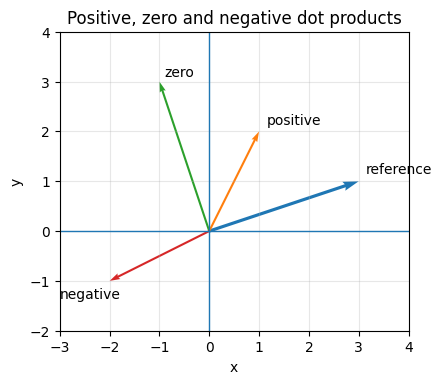

In [6]:
fig, ax = plt.subplots(figsize=(4.5, 4))
setup_vector_plot(
    ax,
    "Positive, zero and negative dot products",
    xlim=(-3, 4),
    ylim=(-2, 4),
)

draw_vector(
    ax,
    reference,
    label="reference",
    label_offset=(0.15, 0.15),
    color="C0",
    width=0.009,
)

draw_vector(
    ax,
    positive_alignment,
    label="positive",
    label_offset=(0.15, 0.15),
    color="C1",
)

draw_vector(
    ax,
    orthogonal,
    label="zero",
    label_offset=(0.1, 0.1),
    color="C2",
)

draw_vector(
    ax,
    negative_alignment,
    label="negative",
    label_offset=(-1.0, -0.35),
    color="C3",
)

plt.show()


The sign of the dot product gives a first clue about direction.

Positive, zero and negative are not arbitrary labels here. They correspond to broadly similar direction, right angle, and broadly opposite direction.


## Dot product size: alignment and length

The sign of the dot product tells us whether two vectors point broadly in the same or opposite directions.

The size of the dot product is affected by two things:

1. how aligned the vectors are
2. how long the vectors are

This means a large dot product can happen because vectors are well-aligned, because they are long, or both.


In [7]:
reference = np.array([3, 1])

small_aligned = np.array([1, 0])
larger_aligned = np.array([3, 1])
huge_aligned = np.array([9, 3])
less_aligned = np.array([0, 3])

print_dot("reference · small_aligned", reference, small_aligned)
print_dot("reference · larger_aligned", reference, larger_aligned)
print_dot("reference · huge_aligned", reference, huge_aligned)
print_dot("reference · less_aligned", reference, less_aligned)


reference · small_aligned: 3.00
reference · larger_aligned: 10.00
reference · huge_aligned: 30.00
reference · less_aligned: 3.00


Notice that `small_aligned` and `less_aligned` give the same dot product, even though they point in different directions.

That is because the dot product combines direction and length into a single number.


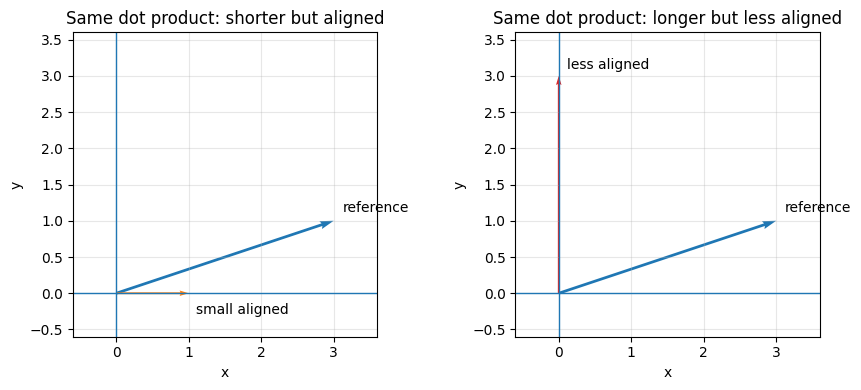

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

shared_xlim = (-0.6, 3.6)
shared_ylim = (-0.6, 3.6)

setup_vector_plot(
    axes[0],
    "Same dot product: shorter but aligned",
    xlim=shared_xlim,
    ylim=shared_ylim,
)
setup_vector_plot(
    axes[1],
    "Same dot product: longer but less aligned",
    xlim=shared_xlim,
    ylim=shared_ylim,
)

for ax in axes:
    draw_vector(
        ax,
        reference,
        label="reference",
        label_offset=(0.12, 0.12),
        color="C0",
        width=0.009,
    )

draw_vector(
    axes[0],
    small_aligned,
    label="small aligned",
    label_offset=(0.1, -0.28),
    color="C1",
)

draw_vector(
    axes[1],
    less_aligned,
    label="less aligned",
    label_offset=(0.12, 0.1),
    color="C3",
)

plt.tight_layout()
plt.show()


The visual comparison is the important point.

The left vector is shorter but well-aligned with the reference vector. The right vector is longer but less aligned with it. In this example, those two effects balance out and produce the same dot product.


## Is there a maximum or minimum dot product?

If vector lengths are unrestricted, there is no fixed maximum or minimum dot product.

A vector can be made longer and longer in the same direction, making the dot product more and more positive.

A vector can also be made longer and longer in the opposite direction, making the dot product more and more negative.

However, for a fixed pair of non-zero vector lengths, there is a maximum and minimum possible dot product:

$$
-\|a\|\|b\| \le a \cdot b \le \|a\|\|b\|
$$

The maximum happens when the vectors point in the same direction.

The minimum happens when the vectors point in opposite directions.

The non-zero detail matters because a zero vector has length zero, but no meaningful direction.


In [9]:
a = np.array([3, 1])
b = np.array([1, 2])

actual_dot = a @ b
maximum_possible_dot = np.linalg.norm(a) * np.linalg.norm(b)
minimum_possible_dot = -maximum_possible_dot

print_dot("a · b", a, b)
print(f"maximum possible dot product = {maximum_possible_dot:.2f}")
print(f"minimum possible dot product = {minimum_possible_dot:.2f}")


a · b: 5.00
maximum possible dot product = 7.07
minimum possible dot product = -7.07


This gives us a way to ask how close the actual dot product is to the largest possible dot product for vectors of those lengths.


## Normalised dot product: measuring direction only

The dot product combines direction and length.

If we divide the dot product by the product of the two vector lengths, we remove the effect of length:

$$
\frac{a \cdot b}{\|a\|\|b\|}
$$

This value is the cosine of the angle between the vectors:

$$
\cos(\theta) = \frac{a \cdot b}{\|a\|\|b\|}
$$

It is also called **cosine similarity**.

Cosine similarity is only defined for non-zero vectors, because we divide by the vector lengths.


In [10]:
a = np.array([3, 1])
b = np.array([1, 2])

dot = a @ b
norm_product = np.linalg.norm(a) * np.linalg.norm(b)
cos_sim = cosine_similarity(a, b)

print_dot("a · b", a, b)
print(f"||a|| ||b|| = {norm_product:.2f}")
print(f"cosine similarity = {cos_sim:.2f}")


a · b: 5.00
||a|| ||b|| = 7.07
cosine similarity = 0.71


## Dot product, lengths and angles

The formula below pulls the ideas together:

$$
a \cdot b = \|a\|\|b\|\cos(\theta)
$$

This means the dot product is affected by both vector length and direction.

For vectors pointing in broadly the same direction, making them longer makes the dot product more positive.

For vectors pointing in opposite directions, making them longer makes the dot product more negative.

Cosine similarity keeps only the $\cos(\theta)$ part.


In [11]:
angle_radians = np.arccos(cos_sim)
angle_degrees = np.degrees(angle_radians)

print(f"angle in degrees = {angle_degrees:.2f}")


angle in degrees = 45.00


## Cosine similarity as direction

Cosine similarity measures direction after length has been divided away.

For non-zero vectors:

- $1$ means same direction
- $0$ means right angle
- $-1$ means opposite direction

A long vector and a short vector can have the same cosine similarity if they point in the same direction.


In [12]:
reference = np.array([2, 1])

same_direction = np.array([4, 2])
short_same_direction = np.array([1, 0.5])
right_angle = np.array([-1, 2])
opposite_direction = np.array([-2, -1])

comparisons = [
    ("same_direction", same_direction),
    ("short_same_direction", short_same_direction),
    ("right_angle", right_angle),
    ("opposite_direction", opposite_direction),
]

for name, vector in comparisons:
    print(f"cosine_similarity(reference, {name}) = {cosine_similarity(reference, vector):.2f}")


cosine_similarity(reference, same_direction) = 1.00
cosine_similarity(reference, short_same_direction) = 1.00
cosine_similarity(reference, right_angle) = 0.00
cosine_similarity(reference, opposite_direction) = -1.00


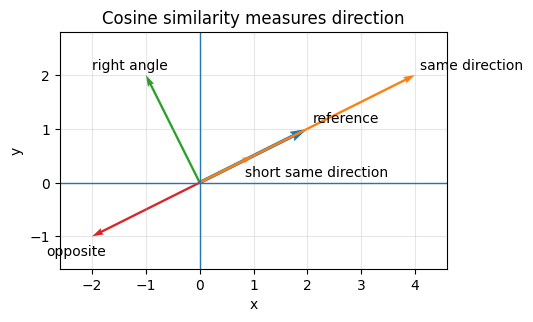

In [13]:
fig, ax = plt.subplots(figsize=(5, 4.5))
setup_vector_plot(
    ax,
    "Cosine similarity measures direction",
    xlim=(-2.6, 4.6),
    ylim=(-1.6, 2.8),
)

draw_vector(
    ax,
    reference,
    label="reference",
    label_offset=(0.1, 0.12),
    color="C0",
    width=0.009,
)

draw_vector(
    ax,
    same_direction,
    label="same direction",
    label_offset=(0.1, 0.1),
    color="C1",
)

draw_vector(
    ax,
    short_same_direction,
    label="short same direction",
    label_offset=(-0.15, -0.38),
    color="C1",
    alpha=0.65,
)

draw_vector(
    ax,
    right_angle,
    label="right angle",
    label_offset=(-1.0, 0.1),
    color="C2",
)

draw_vector(
    ax,
    opposite_direction,
    label="opposite",
    label_offset=(-0.85, -0.35),
    color="C3",
)

plt.show()


The long and short same-direction vectors have the same cosine similarity with the reference vector.

Their dot products would be different because their lengths are different. Their cosine similarities are the same because their direction is the same.


## Optional NumPy note: `np.dot(a, b)` vs `a @ b`

For one-dimensional NumPy arrays, both of these calculate the dot product:

```python
np.dot(a, b)
a @ b
```

For the simple vector examples in this notebook, there is no meaningful performance difference.

There is a semantic difference once arrays become higher-dimensional:

- `np.dot(a, b)` is NumPy's older dot-product function
- `a @ b` uses Python's matrix multiplication operator
- for one-dimensional vectors, they behave like a dot product
- for two-dimensional arrays, `a @ b` means matrix multiplication
- for higher-dimensional arrays, the rules differ in more subtle ways

In modern numerical Python, `@` is often clearer when the operation is meant to represent linear algebra.


## Summary

The dot product combines direction and length.

A dot product takes two vectors with the same number of components and produces a scalar.

For two non-zero vectors $a$ and $b$:

$$
a \cdot b = \|a\|\|b\|\cos(\theta)
$$

So the size and sign of the dot product are affected by both vector length and direction.

- Long vectors pointing in the same direction produce a strongly positive dot product.
- Vectors at right angles produce a dot product of zero.
- Long vectors pointing in opposite directions produce a strongly negative dot product.

For fixed non-zero vector lengths:

$$
-\|a\|\|b\| \le a \cdot b \le \|a\|\|b\|
$$

Cosine similarity divides out the lengths:

$$
\cos(\theta) = \frac{a \cdot b}{\|a\|\|b\|}
$$

So cosine similarity focuses on direction:

- $1$ means same direction
- $0$ means right angle
- $-1$ means opposite direction

Cosine similarity is only defined when both vectors are non-zero, because it divides by the vector lengths.

The central idea: **dot product measures alignment mixed with length; cosine similarity measures alignment without length.**
